In [3]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [2]:
df = pd.read_csv('data/Mall_Customers.csv')
df.drop('CustomerID', axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Genre                   200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


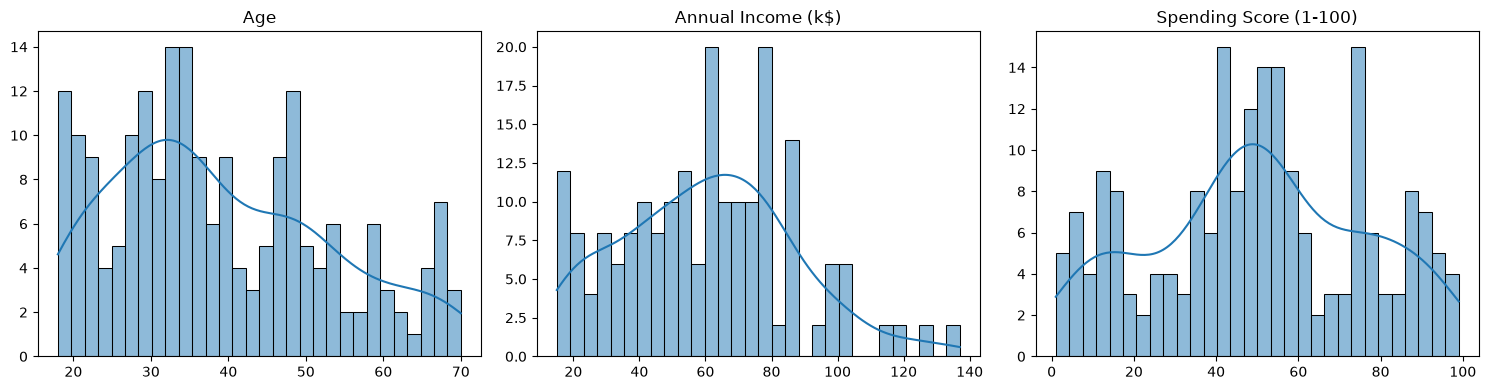

In [4]:
def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

plot_all_histograms(df)

In [5]:
label_encoder = LabelEncoder()
df['Genre'] = label_encoder.fit_transform(df['Genre'])

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

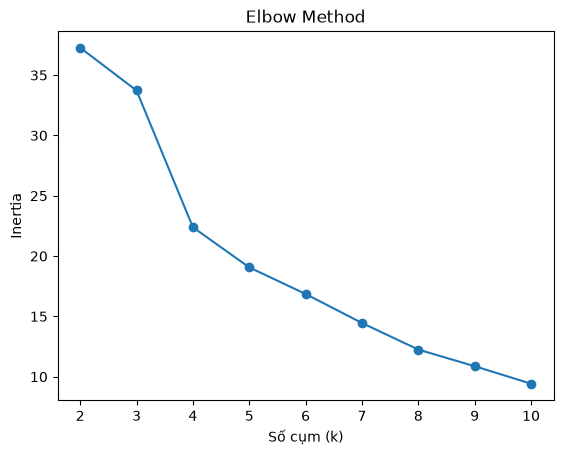

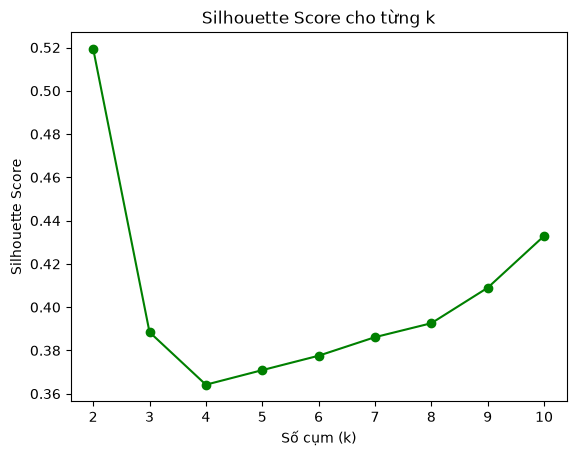

In [6]:
inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Số cụm (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.plot(k_values, silhouette_scores, marker="o", color="green")
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score cho từng k")
plt.show()

In [8]:
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal K by Silhouette Score: {optimal_k}")
print(f"Highest Silhouette Score: {max(silhouette_scores):.3f}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

silhouette_score(df_scaled, kmeans.labels_)

Optimal K by Silhouette Score: 2
Highest Silhouette Score: 0.519


0.4329135031290922